In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
from hydra.utils import instantiate
from hydra import initialize, compose
import hydra

import wandb

from data.dataManager import DataManager
from model.modelCreator import ModelCreator
from omegaconf import OmegaConf
from scripts.run import setup_model, load_model_instance

from utils.displays.shower_plots import visualize_low_ratio_events

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/leozhu/CaloQuVAE/utils/displays/shower_plots.py:758: SyntaxWarning: invalid escape sequence '\S'
  f"$\Sigma GT$={total_dep_gt:.0f} | $\Sigma M$={total_dep_model:.0f}\n"
/home/leozhu/CaloQuVAE/utils/displays/shower_plots.py:758: SyntaxWarning: invalid escape sequence '\S'
  f"$\Sigma GT$={total_dep_gt:.0f} | $\Sigma M$={total_dep_model:.0f}\n"


In [2]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None, config_path="config")
cfg=compose(config_name="config.yaml")
wandb.init(tags = [cfg.data.dataset_name], project=cfg.wandb.project, entity=cfg.wandb.entity, config=OmegaConf.to_container(cfg, resolve=True), mode='disabled')
self = setup_model(cfg)

[18:03:18.017] INFO   data.dataManager                                  Loading ATLAS dataset: AtlasCustomE1
[18:03:24.046] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=448913, Val=49872
[18:03:24.050] INFO   data.dataManager                                  Train: 448913 events, 877 batches
[18:03:24.051] INFO   data.dataManager                                  Val: 49872 events, 49 batches
[18:03:24.052] INFO   data.dataManager                                  Test: 15 events, 1 batches
[18:03:24.053] INFO   model.modelCreator                                ::Creating Model
[18:03:42.866] INFO   model.rbm.zephyr                                  RBM is configured to be fully connected.
[18:03:42.869] INFO   model.rbm.rbm_fulltorch                           RBMTorchFull initialized
[18:03:43.845] INFO   scripts.run                                       Requesting GPUs. GPU list :[4]
[18:03:43.846] INFO   scripts.run                

Using conditional latent size in decoder
cuda:4


In [18]:
self.model.eval()
ar_input_size = self._config.data.z * self._config.data.r * self._config.data.phi
bs = [batch[0].shape[0] for batch in self.data_mgr.train_loader]
showers = torch.zeros(sum(bs), ar_input_size)
incident_energies = torch.zeros((sum(bs), 1))
with torch.no_grad():
    for i, (x, x0) in enumerate(self.data_mgr.train_loader):
        idx1, idx2 = int(np.sum(bs[:i])), int(np.sum(bs[:i+1]))
        incident_energies[idx1:idx2,:] = x0.cpu()
        showers[idx1:idx2,:] = x.cpu()




--- Visualizing Low Ratio Events (Ratio < 0.5) ---
Total Events: 448913
Events below cutoff: 9 (0.00%)


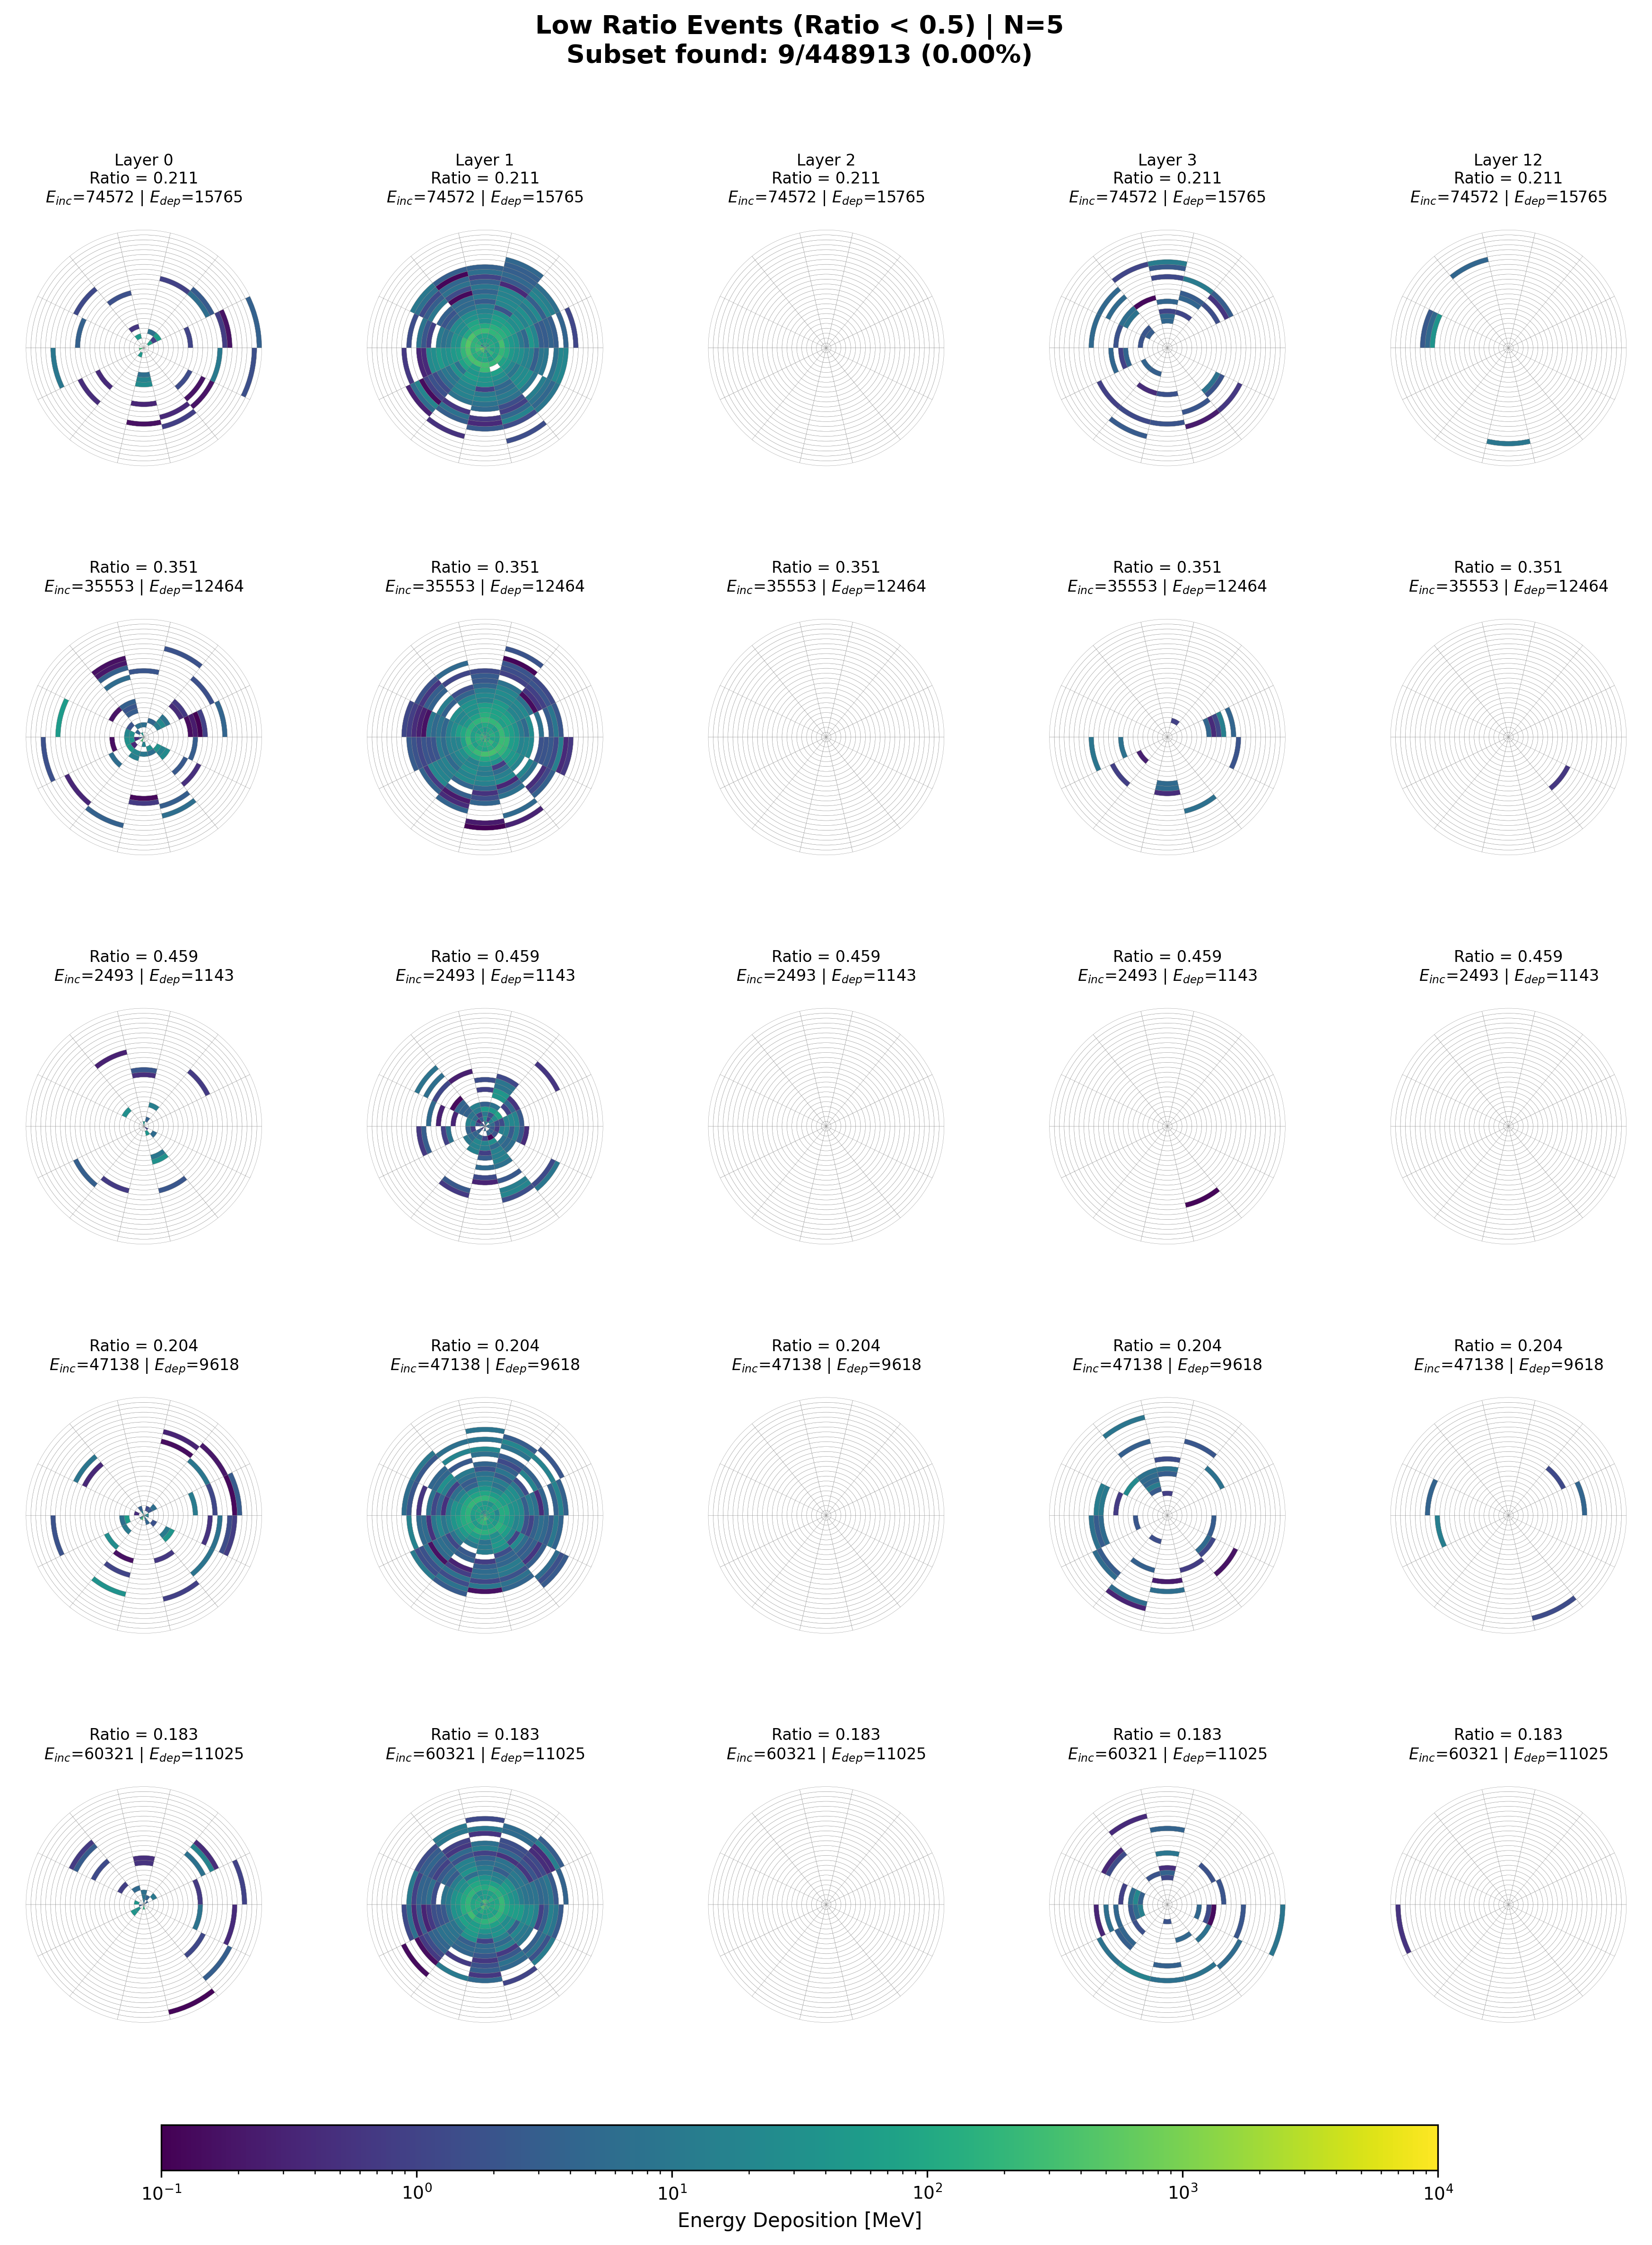

In [21]:
visualize_low_ratio_events(showers=showers, 
                           e_inc=incident_energies,
                           binning_path=self._config.data.binning_path,
                           cutoff=0.5,
                           )